# Representation of Scenario Tree of Day Ahead Scenario followed by K Intraday Scenarios

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from helper_funcs import load_csvs_with_substring

In [2]:
# Load k from config.json
with open("config.json", "r") as file:
    config = json.load(file)

k = int(config.get("cluster", 10))          # Default to 10 if key is not found
cluster_name = f'C{k}'

In [3]:
def plot_scenario_tree(da_actual, id_actual, da_forecast, id_scenarios, clusternum, date, path=None):
    """
    Plots or saves the scenario tree for electricity market prices with improved ID scenario distinction.

    Parameters:
    - da_actual (DataFrame or array): Actual day-ahead prices, shape (24, 1).
    - id_actual (DataFrame or array): Actual intraday prices, shape (24, 1).
    - da_forecast (DataFrame or array): Day-ahead forecast, shape (24, 1).
    - id_scenarios (DataFrame or array): Intraday scenarios, shape (10, 24).
    - clusternum (int): Cluster number for labeling the plot.
    - date (str): Date for labeling the plot.
    - path (str, optional): File path to save the plot. If None, the plot will be displayed.
    """
    # Ensure inputs are NumPy arrays
    da_actual = np.array(da_actual).flatten()
    id_actual = np.array(id_actual).flatten()
    da_forecast = np.array(da_forecast).flatten()
    id_scenarios = np.array(id_scenarios)

    # Time axis (24 hours)
    hours = np.arange(0, 25, 1)  # Ensures 0 to 24 hours

    # Define different linestyles for ID scenarios to improve visibility
    linestyles = ['dashed', 'dashdot', 'solid', (0, (3, 1, 1, 1)), (0, (1, 1))]

    # Create the figure (horizontal orientation)
    fig, ax = plt.subplots(figsize=(8, 4))  

    # Ensure white background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Plot ID scenarios with varying line styles and transparency
    for i, id_scenario in enumerate(id_scenarios):
        linestyle = linestyles[i % len(linestyles)]  # Cycle through different styles
        ax.plot(hours[:-1], id_scenario, linestyle=linestyle, color="darkorange", linewidth=1.2, alpha=0.7, label=f"ID_{i+1}" if i < 5 else None)

    # Plot actual DA prices (historical)
    ax.plot(hours[:-1], da_actual, color="black", linewidth=1.5, linestyle="-", label="Historical DA Price")

    # Plot actual ID prices (black dotted line)
    ax.plot(hours[:-1], id_actual, color="black", linewidth=1.2, linestyle="dotted", label="ID Actual Price")

    # Plot DA forecast
    ax.plot(hours[:-1], da_forecast, linestyle="-", color="lightblue", linewidth=1.5, label="DA Forecast")

    # Improve axis labels and ticks
    ax.set_ylabel("EUR/MWh", fontsize=12, labelpad=10)
    ax.set_xticks(np.arange(0, 25, 3))  # Set x-ticks every 3 hours
    ax.set_xticklabels([f"{h}:00" for h in range(0, 25, 3)], fontsize=10)

    # Adjust legend to bottom-left
    ax.legend(fontsize=10, loc="lower left", frameon=True, bbox_to_anchor=(1, 0.25))

    # Title
    ax.set_title(f"Scenario Tree Cluster {clusternum}", fontsize=14, weight='bold')

    # Save the plot if a path is provided, otherwise display it
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=300)
        plt.close()  # Close the plot to free memory
    else:
        plt.show()


## Testing For a Particular Date a Scenario Tree

In [4]:
# for a particular date
date = '2024-09-17'
cluster = 'C10'

In [5]:
# Loading DA scenario
DA_scenarios = pd.read_csv(f'reduced_scenarios/{cluster}/da/scenario_{date}.csv').iloc[:,1:]
DA_actual = pd.read_csv(f'scenarios/da/prices_{date}.csv', index_col=0)
ID_actual = pd.read_csv(f'scenarios/id/{cluster}/prices_{date}.csv', index_col=0)

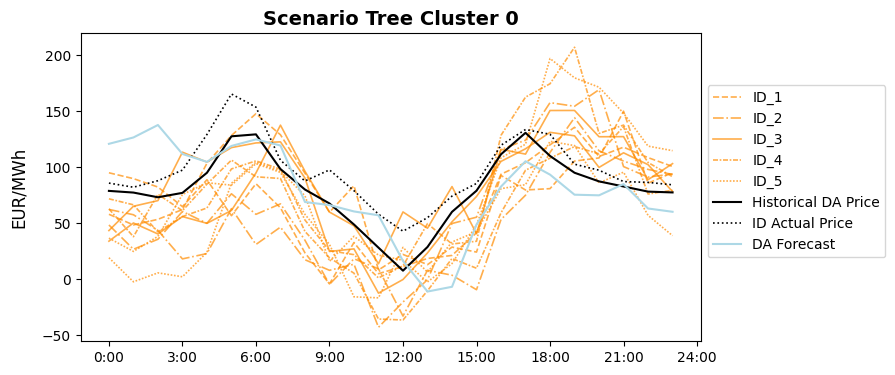

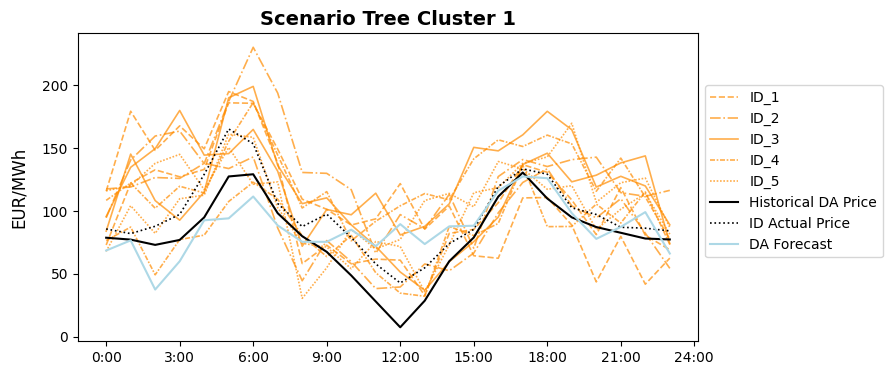

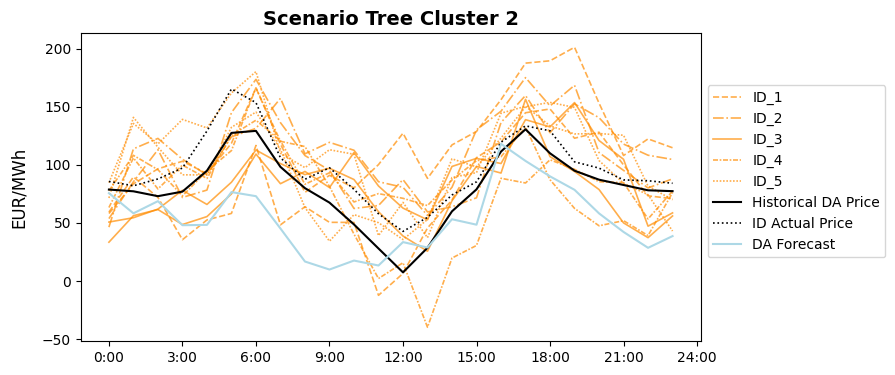

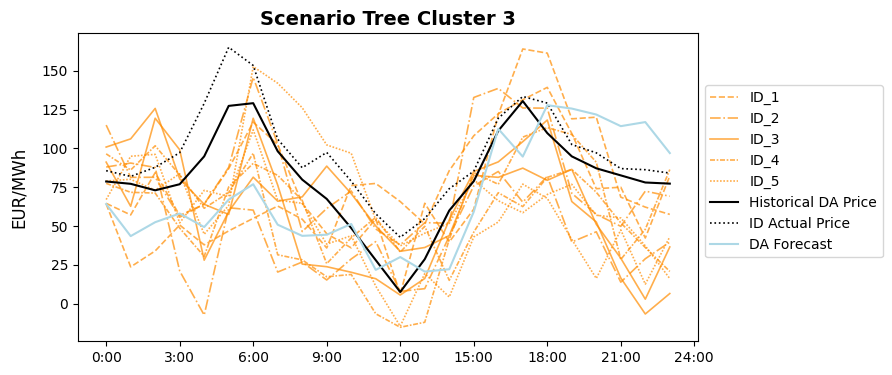

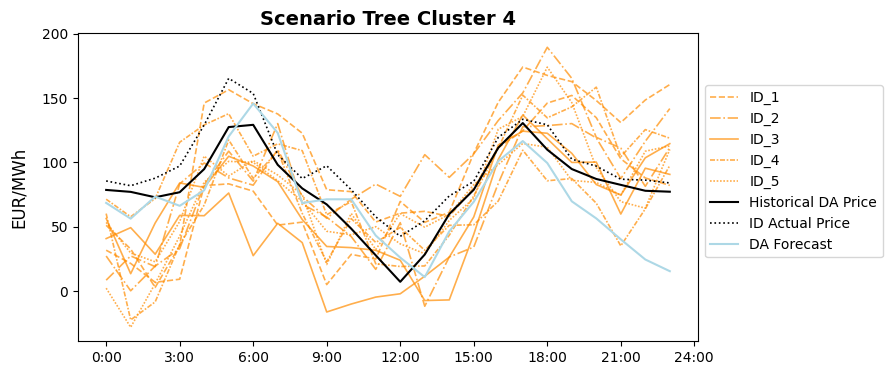

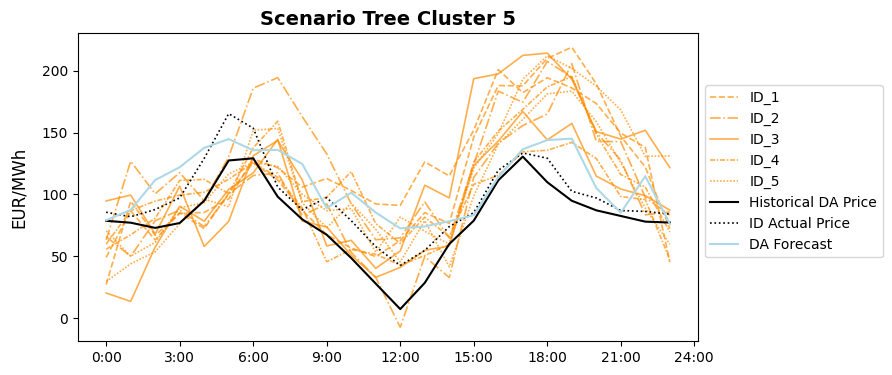

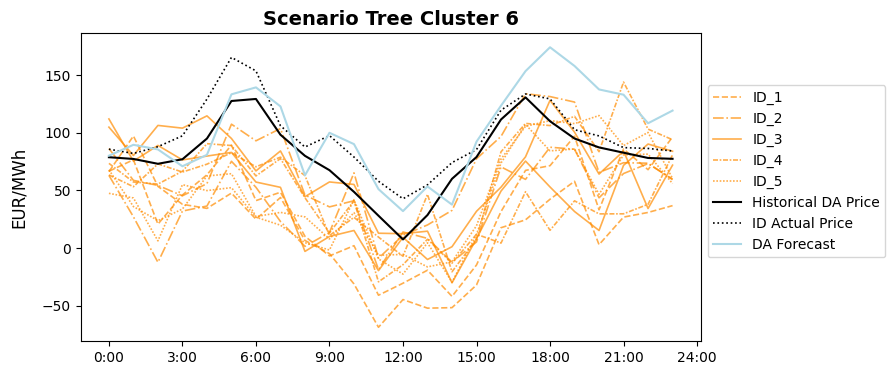

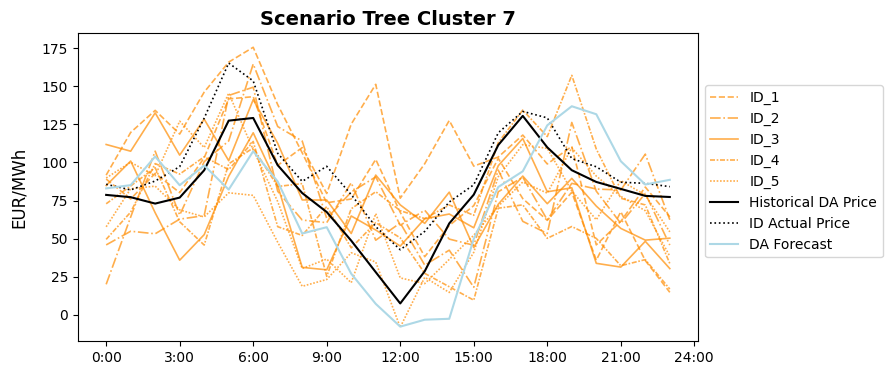

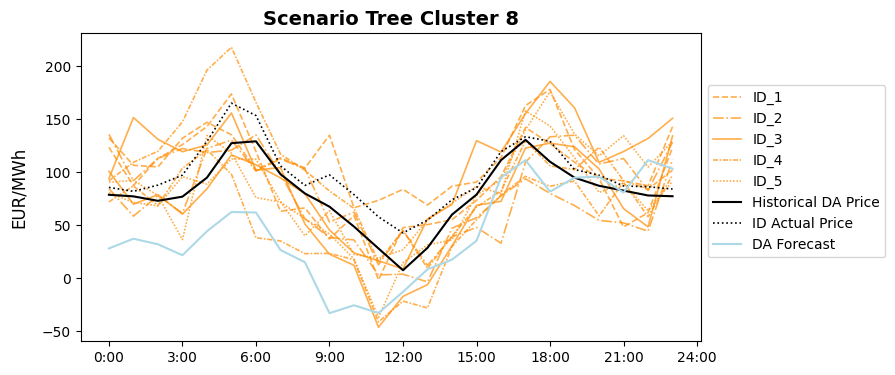

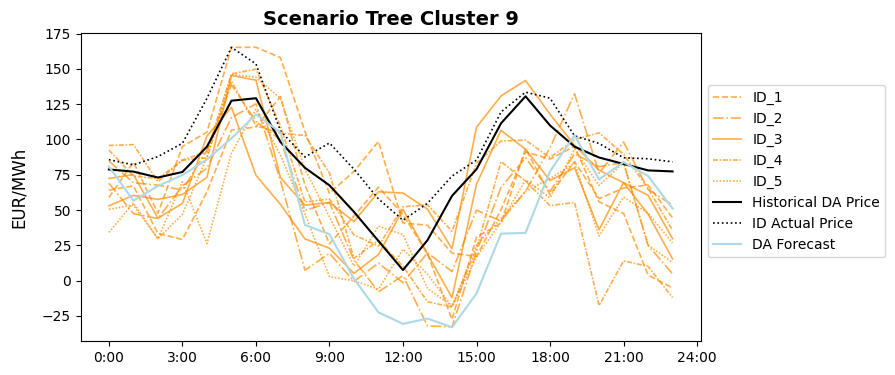

In [6]:
for idx, DA_scen in DA_scenarios.iterrows():
    # load intraday scenarios for each day ahead scenario
    ID_scenarios = pd.read_csv(f'reduced_scenarios/{cluster}/id/scenario_{idx}_{date}.csv').iloc[:,1:]
    plot_scenario_tree(DA_actual, ID_actual, DA_scen, ID_scenarios, idx, date)

## Loading all Day Ahead Reduced Scenarios & Saving Images

In [7]:
# Specify the directory containing your CSV files
directory_path = f'reduced_scenarios/{cluster_name}/da'

# Define the substring to match in filenames
substring_to_match = 'scenario'

# Load the CSV files 
scenarios_df, dates = load_csvs_with_substring(directory_path, substring_to_match)
prices_df_da, dates_p_da = load_csvs_with_substring('scenarios/da', "prices")
prices_df_id, dates_p_id = load_csvs_with_substring(f'scenarios/id/{cluster_name}', "prices")

In [8]:
# Iterate over each cluster and date to generate plots
for idx, da_cluster in enumerate(scenarios_df):
    file_path_template = f'reduced_scenarios/{cluster}/id/scenario_{{cluster_number}}_{dates[idx]}.csv'
    cluster_numbers = range(int(cluster_name[1:]))  # Adjust the range as per the maximum cluster numbers
    loaded_files = {}

    # Load files for each cluster
    for clusternum, row in da_cluster.iterrows():
        file_path = file_path_template.format(cluster_number=clusternum)
        if os.path.exists(file_path):
            id_scen_cluster = pd.read_csv(file_path).iloc[:,1:]
            path = f'images/scenario_trees/{cluster}/{dates[idx]}_{clusternum}'
            plot_scenario_tree(prices_df_da[idx], prices_df_id[idx], row, id_scen_cluster, clusternum, dates[idx], path)